<a href="https://colab.research.google.com/github/shahdmabdelaziz-hue/Give-Me-some-credit-ML/blob/main/GiveMeSomeCredit_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/cs-training.csv')
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
125108,125109,0,0.000000,76,0,0.000000,NaN,4.0,0.0,0.0,0.0,0.0
125109,125110,0,0.241145,45,0,0.264022,5116.0,9.0,0.0,1.0,0.0,1.0
125110,125111,0,0.368655,41,0,0.411629,2166.0,6.0,1.0,0.0,0.0,3.0
125111,125112,0,0.550178,58,1,0.383287,10829.0,12.0,0.0,2.0,0.0,2.0


In [ ]:
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13.0,0.0,6.0,0.0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2.0,1.0,0.0,0.0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5.0,0.0,0.0,0.0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
125108,0,0.000000,76,0,0.000000,NaN,4.0,0.0,0.0,0.0,0.0
125109,0,0.241145,45,0,0.264022,5116.0,9.0,0.0,1.0,0.0,1.0
125110,0,0.368655,41,0,0.411629,2166.0,6.0,1.0,0.0,0.0,3.0
125111,0,0.550178,58,1,0.383287,10829.0,12.0,0.0,2.0,0.0,2.0


In [ ]:
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,24803
NumberOfOpenCreditLinesAndLoans,1
NumberOfTimes90DaysLate,1
NumberRealEstateLoansOrLines,1
NumberOfTime60-89DaysPastDueNotWorse,1


In [ ]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

print("Missing values after imputation:")
print(df[['MonthlyIncome', 'NumberOfDependents']].isnull().sum())

Missing values after imputation:
MonthlyIncome         0
NumberOfDependents    0
dtype: int64


In [ ]:
df.isnull().sum()

,0
SeriousDlqin2yrs,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,0
NumberOfOpenCreditLinesAndLoans,1
NumberOfTimes90DaysLate,1
NumberRealEstateLoansOrLines,1
NumberOfTime60-89DaysPastDueNotWorse,1


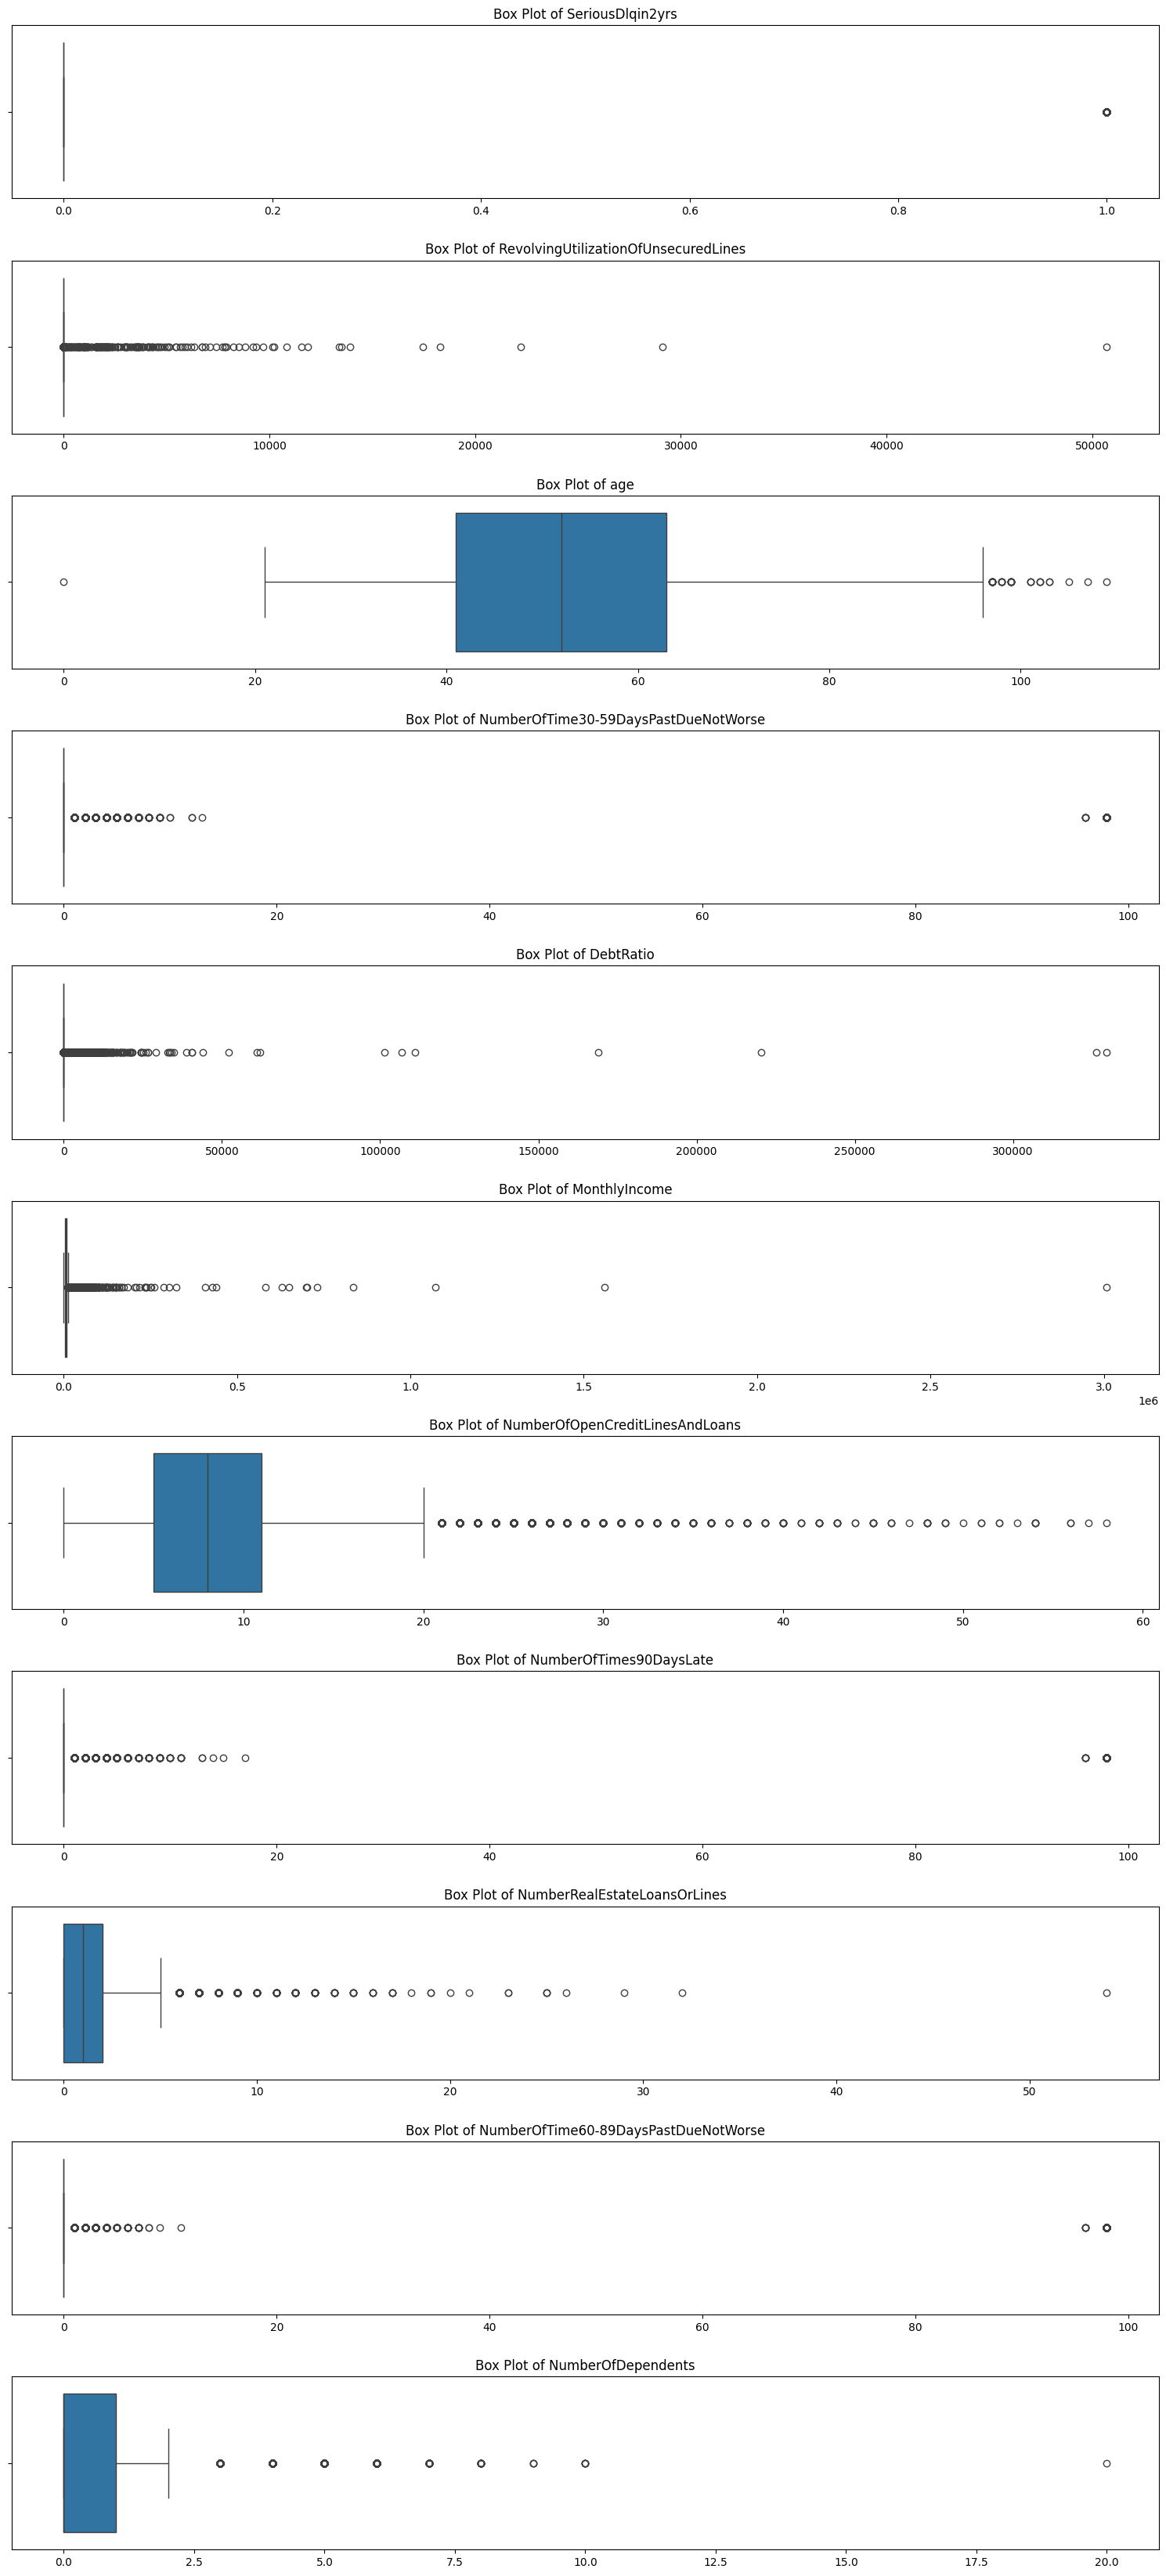

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for box plots
numerical_cols = df.select_dtypes(include=['number']).columns

plt.figure(figsize=(15, len(numerical_cols) * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 1, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

Outliers have been treated by capping at the 1st and 99th percentiles.



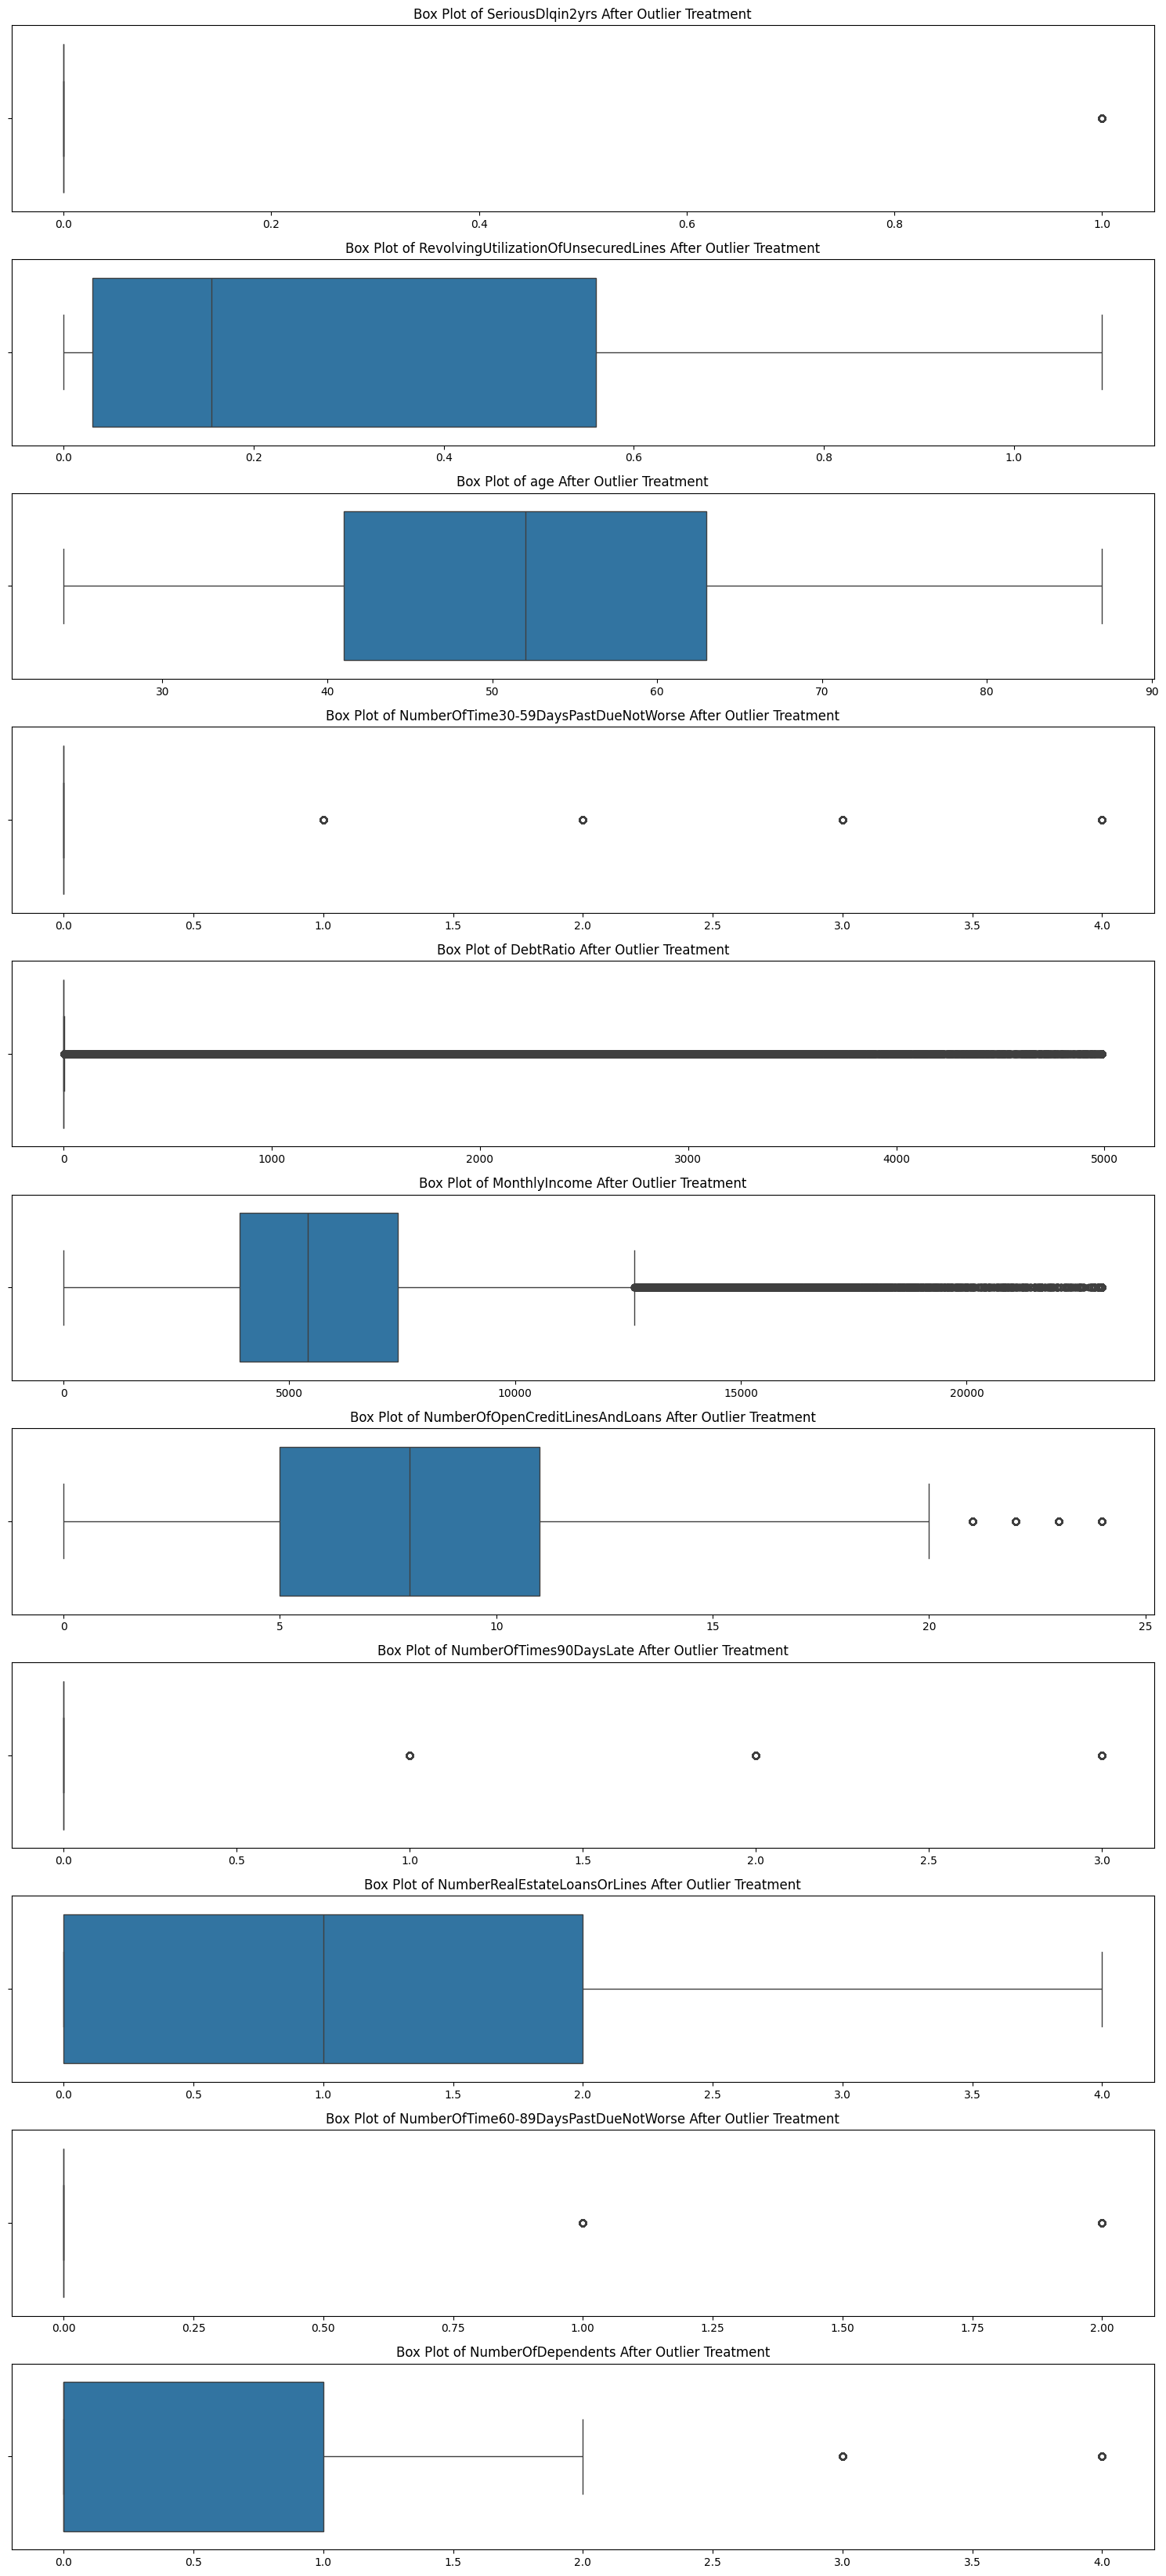

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for outlier treatment
numerical_cols = df.select_dtypes(include=np.number).columns

# Apply capping (Winsorization) to handle outliers
# We will cap values below the 1st percentile and above the 99th percentile
for col in numerical_cols:
    lower_bound = df[col].quantile(0.01)
    upper_bound = df[col].quantile(0.99)
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])

print("Outliers have been treated by capping at the 1st and 99th percentiles.\n")

# Generate new box plots to visualize the effect
plt.figure(figsize=(15, len(numerical_cols) * 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 1, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col} After Outlier Treatment')
    plt.xlabel('')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming 'SeriousDlqin2yrs' is the target variable
X = df.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0'], errors='ignore')
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (100090, 10)
Shape of X_test: (25023, 10)
Shape of y_train: (100090,)
Shape of y_test: (25023,)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Initialize Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' is good for small datasets and handles L1/L2 penalties

# --- FIX: Drop rows with NaN values from X_train, y_train, X_test, and y_test ---
# Identify rows with NaNs in X_train
nan_rows_train = X_train.isnull().any(axis=1)
X_train_cleaned = X_train[~nan_rows_train]
y_train_cleaned = y_train[~nan_rows_train]

# Identify rows with NaNs in X_test
nan_rows_test = X_test.isnull().any(axis=1)
X_test_cleaned = X_test[~nan_rows_test]
y_test_cleaned = y_test[~nan_rows_test]
# -----------------------------------------------------------------------

# Train the model using the cleaned data
log_reg_model.fit(X_train_cleaned, y_train_cleaned)

# Make predictions on the cleaned test set
y_pred = log_reg_model.predict(X_test_cleaned)

# Evaluate the model
accuracy = accuracy_score(y_test_cleaned, y_pred)
print(f"Logistic Regression Model Accuracy: {accuracy:.4f}")

Logistic Regression Model Accuracy: 0.9390


In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the cleaned training set
y_train_pred = log_reg_model.predict(X_train_cleaned)

# Generate and print the classification report for the training data
print("Classification Report for Training Data:")
print(classification_report(y_train_cleaned, y_train_pred))

# Generate and print the classification report for the test data
print("\nClassification Report for Test Data:")
print(classification_report(y_test_cleaned, y_pred))

Classification Report for Training Data:
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97     93438
         1.0       0.60      0.17      0.26      6651

    accuracy                           0.94    100089
   macro avg       0.77      0.58      0.62    100089
weighted avg       0.92      0.94      0.92    100089


Classification Report for Test Data:
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97     23371
         1.0       0.64      0.17      0.27      1652

    accuracy                           0.94     25023
   macro avg       0.79      0.58      0.62     25023
weighted avg       0.92      0.94      0.92     25023



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Decision Tree Classifier model
decision_tree_model = DecisionTreeClassifier(random_state=42)

# Train the model using the cleaned training data
decision_tree_model.fit(X_train_cleaned, y_train_cleaned)

# Make predictions on the cleaned test set
y_pred_dt = decision_tree_model.predict(X_test_cleaned)

# Make predictions on the cleaned training set
y_train_pred_dt = decision_tree_model.predict(X_train_cleaned)

# Evaluate the model accuracy on test set
accuracy_dt = accuracy_score(y_test_cleaned, y_pred_dt)
print(f"Decision Tree Model Test Accuracy: {accuracy_dt:.4f}")

# Generate and print the classification report for the training data
print("\nDecision Tree Classification Report for Training Data:")
print(classification_report(y_train_cleaned, y_train_pred_dt))

# Generate and print the classification report for the test data
print("\nDecision Tree Classification Report for Test Data:")
print(classification_report(y_test_cleaned, y_pred_dt))

Decision Tree Model Test Accuracy: 0.8990

Decision Tree Classification Report for Training Data:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     93438
         1.0       1.00      0.99      1.00      6651

    accuracy                           1.00    100089
   macro avg       1.00      1.00      1.00    100089
weighted avg       1.00      1.00      1.00    100089


Decision Tree Classification Report for Test Data:
              precision    recall  f1-score   support

         0.0       0.95      0.94      0.95     23371
         1.0       0.26      0.29      0.27      1652

    accuracy                           0.90     25023
   macro avg       0.60      0.61      0.61     25023
weighted avg       0.90      0.90      0.90     25023



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Random Forest Classifier model
random_forest_model = RandomForestClassifier(random_state=42)

# Train the model using the cleaned training data
random_forest_model.fit(X_train_cleaned, y_train_cleaned)

# Make predictions on the cleaned test set
y_pred_rf = random_forest_model.predict(X_test_cleaned)

# Make predictions on the cleaned training set
y_train_pred_rf = random_forest_model.predict(X_train_cleaned)

# Evaluate the model accuracy on test set
accuracy_rf = accuracy_score(y_test_cleaned, y_pred_rf)
print(f"Random Forest Model Test Accuracy: {accuracy_rf:.4f}")

# Generate and print the classification report for the training data
print("\nRandom Forest Classification Report for Training Data:")
print(classification_report(y_train_cleaned, y_train_pred_rf))

# Generate and print the classification report for the test data
print("\nRandom Forest Classification Report for Test Data:")
print(classification_report(y_test_cleaned, y_pred_rf))

Random Forest Model Test Accuracy: 0.9373

Random Forest Classification Report for Training Data:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     93438
         1.0       1.00      1.00      1.00      6651

    accuracy                           1.00    100089
   macro avg       1.00      1.00      1.00    100089
weighted avg       1.00      1.00      1.00    100089


Random Forest Classification Report for Test Data:
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97     23371
         1.0       0.57      0.20      0.30      1652

    accuracy                           0.94     25023
   macro avg       0.76      0.59      0.63     25023
weighted avg       0.92      0.94      0.92     25023



In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# Initialize XGBoost Classifier model
# Using a small learning rate and increased estimators for potentially better performance
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric
    use_label_encoder=False,     # Suppress warning for older versions
    n_estimators=200,            # Number of boosting rounds
    learning_rate=0.1,           # Step size shrinkage to prevent overfitting
    random_state=42
)

# Train the model using the cleaned and scaled data
xgb_model.fit(X_train_cleaned_scaled, y_train_cleaned)

# Make predictions on the cleaned and scaled test set
y_pred_xgb = xgb_model.predict(X_test_cleaned_scaled)

# Make predictions on the cleaned and scaled training set
y_train_pred_xgb = xgb_model.predict(X_train_cleaned_scaled)

# Evaluate the model accuracy on test set
accuracy_xgb = accuracy_score(y_test_cleaned, y_pred_xgb)
print(f"XGBoost Model Test Accuracy: {accuracy_xgb:.4f}")

# Generate and print the classification report for the cleaned and scaled training data
print("\nXGBoost Classification Report for Training Data (Cleaned and Scaled):")
print(classification_report(y_train_cleaned, y_train_pred_xgb))

# Generate and print the classification report for the cleaned and scaled test data
print("\nXGBoost Classification Report for Test Data (Cleaned and Scaled):")
print(classification_report(y_test_cleaned, y_pred_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:27:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Model Test Accuracy: 0.9377

XGBoost Classification Report for Training Data (Cleaned and Scaled):
              precision    recall  f1-score   support

         0.0       0.95      1.00      0.97     93438
         1.0       0.82      0.28      0.42      6651

    accuracy                           0.95    100089
   macro avg       0.88      0.64      0.70    100089
weighted avg       0.94      0.95      0.94    100089


XGBoost Classification Report for Test Data (Cleaned and Scaled):
              precision    recall  f1-score   support

         0.0       0.95      0.99      0.97     23371
         1.0       0.58      0.20      0.30      1652

    accuracy                           0.94     25023
   macro avg       0.76      0.59      0.63     25023
weighted avg       0.92      0.94      0.92     25023



In [ ]:
from sklearn.ensemble import IsolationForest

# Initialize the Isolation Forest model
# contamination: The amount of contamination of the data set, i.e. the proportion of outliers in the data set.
# This is an estimate, and a common value for datasets with few outliers is 'auto' or a small fraction like 0.01-0.05.
# For this dataset, let's assume a small percentage of anomalies, e.g., 1%.
iso_forest = IsolationForest(random_state=42, contamination=0.01)

# Fit the model to the training data
# Note: Isolation Forest is an unsupervised algorithm, so it's typically fit on the features only.
iso_forest.fit(X_train_cleaned_scaled)

# Predict anomalies (-1 for outliers, 1 for inliers)
# We'll apply it to the training data to see the detected outliers
y_pred_iso = iso_forest.predict(X_train_cleaned_scaled)

# Count the number of outliers (-1)
outliers = X_train_cleaned_scaled[y_pred_iso == -1]

print(f"Isolation Forest applied to X_train_cleaned_scaled.")
print(f"Number of outliers detected (contamination={iso_forest.contamination}): {len(outliers)}")
print(f"Percentage of outliers detected: {(len(outliers) / len(X_train_cleaned_scaled) * 100):.2f}%")

Isolation Forest applied to X_train_cleaned_scaled.
Number of outliers detected (contamination=0.01): 1001
Percentage of outliers detected: 1.00%


In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Map Isolation Forest predictions:
# -1 (outlier) -> 1 (predicted anomaly/positive class)
#  1 (inlier)  -> 0 (predicted normal/negative class)
y_pred_iso_mapped = np.where(y_pred_iso == -1, 1, 0)

# Generate and print the classification report
# y_true is y_train_cleaned, y_pred is y_pred_iso_mapped
print("Classification Report for Isolation Forest (against SeriousDlqin2yrs target):\n")
print(classification_report(y_train_cleaned, y_pred_iso_mapped))

Classification Report for Isolation Forest (against SeriousDlqin2yrs target):

              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97     93438
         1.0       0.53      0.08      0.14      6651

    accuracy                           0.93    100089
   macro avg       0.73      0.54      0.55    100089
weighted avg       0.91      0.93      0.91    100089



In [ ]:
import numpy as np
from sklearn.metrics import classification_report

# Predict anomalies on the scaled test data
y_pred_iso_test = iso_forest.predict(X_test_cleaned_scaled)

# Map Isolation Forest predictions for test data:
# -1 (outlier) -> 1 (predicted anomaly/positive class)
#  1 (inlier)  -> 0 (predicted normal/negative class)
y_pred_iso_test_mapped = np.where(y_pred_iso_test == -1, 1, 0)

# Generate and print the classification report for the test data
print("\nClassification Report for Isolation Forest on Test Data (against SeriousDlqin2yrs target):\n")
print(classification_report(y_test_cleaned, y_pred_iso_test_mapped))


Classification Report for Isolation Forest on Test Data (against SeriousDlqin2yrs target):

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97     23371
         1.0       0.61      0.09      0.16      1652

    accuracy                           0.94     25023
   macro avg       0.77      0.55      0.57     25023
weighted avg       0.92      0.94      0.91     25023



In [ ]:

n_negative = (y_train_cleaned == 0).sum()
n_positive = (y_train_cleaned == 1).sum()
weight = n_negative / n_positive

import xgboost as xgb
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=weight,
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train_cleaned_scaled, y_train_cleaned)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import classification_report

# Make predictions on the cleaned and scaled training set using the retrained xgb_model
y_train_pred_xgb_weighted = xgb_model.predict(X_train_cleaned_scaled)

# Generate and print the classification report for the cleaned and scaled training data
print("XGBoost Classification Report for Training Data (Weighted and Scaled):\n")
print(classification_report(y_train_cleaned, y_train_pred_xgb_weighted))

# Make predictions on the cleaned and scaled test set using the retrained xgb_model
y_pred_xgb_weighted = xgb_model.predict(X_test_cleaned_scaled)

# Generate and print the classification report for the cleaned and scaled test data
print("\nXGBoost Classification Report for Test Data (Weighted and Scaled):\n")
print(classification_report(y_test_cleaned, y_pred_xgb_weighted))

XGBoost Classification Report for Training Data (Weighted and Scaled):

              precision    recall  f1-score   support

         0.0       0.99      0.84      0.91     93438
         1.0       0.27      0.84      0.41      6651

    accuracy                           0.84    100089
   macro avg       0.63      0.84      0.66    100089
weighted avg       0.94      0.84      0.87    100089


XGBoost Classification Report for Test Data (Weighted and Scaled):

              precision    recall  f1-score   support

         0.0       0.98      0.83      0.90     23371
         1.0       0.23      0.74      0.35      1652

    accuracy                           0.82     25023
   macro avg       0.61      0.78      0.63     25023
weighted avg       0.93      0.82      0.86     25023



In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
import numpy as np


X_train_normal = X_train_cleaned_scaled[y_train_cleaned.values == 0] # Fixed: Use .values to avoid index misalignment
input_dim = X_train_normal.shape[1]

input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation="relu")(input_layer)
encoder = Dense(8, activation="relu")(encoder)
decoder = Dense(16, activation="relu")(encoder)
output_layer = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# التدريب
autoencoder.fit(X_train_normal, X_train_normal,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_split=0.1,
                verbose=1)

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5056 - val_loss: 0.2401
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1693 - val_loss: 0.1205
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0872 - val_loss: 0.0632
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0531 - val_loss: 0.0442
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0411 - val_loss: 0.0359
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0342 - val_loss: 0.0302
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0300 - val_loss: 0.0270
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0270 - val_loss: 0.0236
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0237 - val_loss: 0.0213
Epoch 10/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0214 - val_loss: 0.0192
Epoch 11/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0199 - val_loss: 0.0182
Epoch 12/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [ ]:
# حساب الخطأ (Reconstruction Error) على بيانات الاختبار (Test)
reconstructions = autoencoder.predict(X_test_cleaned_scaled)
mse_loss = np.mean(np.power(X_test_cleaned_scaled - reconstructions, 2), axis=1)

# عشان نرفع الـ Recall، بنخلي الـ Threshold حساس (يعني بنقلل العتبة عشان نصطاد حالات أكتر)
# ممكن نحدد العتبة بناءً على النسبة المئوية للمتعثرين في الداتا
threshold = np.percentile(mse_loss, 85) # كل ما قللنا الرقم أو زودنا النسبة، الـ Recall هيعلى

# التنبؤ (لو الخطأ أكبر من العتبة يبقى متعثر 1، غير كده سليم 0)
y_pred_ae = (mse_loss > threshold).astype(int)

# طباعة التقرير
from sklearn.metrics import classification_report
print(classification_report(y_test_cleaned, y_pred_ae))

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

         0.0       0.96      0.88      0.92     23371
         1.0       0.24      0.54      0.33      1652

    accuracy                           0.86     25023
   macro avg       0.60      0.71      0.63     25023
weighted avg       0.92      0.86      0.88     25023



In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Calculate reconstruction error for the training data
reconstructions_train = autoencoder.predict(X_train_cleaned_scaled)
mse_train = np.mean(np.power(X_train_cleaned_scaled - reconstructions_train, 2), axis=1)

# Define y_pred for training data using the same threshold derived from test data
y_pred_ae_train = (mse_train > threshold).astype(int)

# Print classification report for training data
print("\nClassification Report for Autoencoder on Training Data (against SeriousDlqin2yrs target):\n")
print(classification_report(y_train_cleaned, y_pred_ae_train))

# Print classification report for test data (y_pred_ae and threshold were already calculated in RXx1ySdiF-bK)
print("\nClassification Report for Autoencoder on Test Data (against SeriousDlqin2yrs target):\n")
print(classification_report(y_test_cleaned, y_pred_ae))

3128/3128 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step

Classification Report for Autoencoder on Training Data (against SeriousDlqin2yrs target):

              precision    recall  f1-score   support

         0.0       0.96      0.88      0.92     93438
         1.0       0.23      0.53      0.32      6651

    accuracy                           0.85    100089
   macro avg       0.60      0.70      0.62    100089
weighted avg       0.91      0.85      0.88    100089


Classification Report for Autoencoder on Test Data (against SeriousDlqin2yrs target):

              precision    recall  f1-score   support

         0.0       0.96      0.88      0.92     23371
         1.0       0.24      0.54      0.33      1652

    accuracy                           0.86     25023
   macro avg       0.60      0.71      0.63     25023
weighted avg       0.92      0.86      0.88     25023

